In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import warnings
warnings.filterwarnings("ignore")
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/llm-prediction/predictions (1).csv
/kaggle/input/dataset/Fake_dev.csv
/kaggle/input/dataset/Fake_train.csv
/kaggle/input/dataset/Fake_test_with_labels.csv
/kaggle/input/dataset/Fake_test_without_labels.csv


In [2]:
df_train1 = pd.read_csv('/kaggle/input/dataset/Fake_train.csv')
df_train2 = pd.read_csv('/kaggle/input/dataset/Fake_dev.csv')
df_test = pd.read_csv('/kaggle/input/dataset/Fake_test_without_labels.csv')
real_df = pd.read_csv('/kaggle/input/dataset/Fake_test_with_labels.csv')
real_df

,text,label
0,5000 ഉള്ള പോൾ ലോഗ്‌ഡ്‌വൻ ഇപ്പോള് 250000 എന്താ...,Fake
1,ഓഷോ രജനീഷ് പറഞ്ഞപോലെ എനിക്കപ്പോൾ തോന്നിയത് അ...,Fake
2,ചേട്ടാ വാർത്ത വയ്ക്കുന്നത് കേരളത്തിലാണ് സം...,Fake
3,Shame for entire Woman&#39;s of Kerala,original
4,135 code janaghal andhu wide business cheythal...,Fake
...,...,...
1014,Correct ...China cheitha ...weapon spread ing ...,Fake
1015,ഈ WHO പറയുന്നതനുസരിച്ചു ചികിത്സയും ലോക്ക് ഡൌൺ ...,Fake
1016,Mask illa aarkum😏😏,original
1017,ഇയാളെ കൊറോണ. രോഗി കൾ കിടയിൽ. ഇടാമായിരുന്നു---!!,Fake


In [51]:
df_train2

,text,label
0,Full. Musilm. Verodamum,Fake
1,പക്ഷികളും മൃഗങ്ങളും ഈ ലോകത്ത് സുഖമായി ജീവിക്കു...,Fake
2,ഒരു താടിക്കാരൻ പാത്രം കൊട്ടാൻ പറഞ്ഞപ്പോ .........,original
3,കുംഭളേമ<br>മറന്നോ,original
4,ഇത് തിരുവാതിര അല്ല...... കോറോണയെ കൈകൊട്ടി കൊല്...,original
...,...,...
810,ജനങ്ങൾ വിഡ്ഢികളല്ല .. അത്രേ പറയാനുള്ളു,original
811,😂😂ഒരു പിണറായി,original
812,Mr sir are you know about bodhidarma the great...,Fake
813,ബുദ്ധിയുള്ളവരെ വിജയിപ്പിക്,Fake


In [13]:
#import torch
#random_state = 42
#torch.manual_seed(random_state)
#np.random.seed(random_state)

In [3]:
# Concatenate df_val to df_train
df_train = pd.concat([df_train1, df_train2], ignore_index=True)
df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)
# Optionally, reset the index (if you want a continuous index after concatenation)
#df_train.reset_index(drop=True, inplace=True)

In [4]:
df_train

,text,label
0,പൊളിച്ചു ബ്രോ.. 🤣🤣,original
1,Natil oru maranam undu thiruvathira book chayumo,original
2,നാണമില്ലേ നാരികൾക്ക്,original
3,നാളെ എന്റെ കല്യാണം ആണ് 100പേരെ വിളിച്ചിട്ടുള്ള...,original
4,ഈ പുള്ളിയെ എവിടുന്നു കിട്ടി സൂപ്പർ പൊളി മനുഷ...,original
...,...,...
4067,Udfkare maranathinte vyaparikal ennu vilicha K...,original
4068,Evanmark eni ennavum budhi udikkunnat. Tphoooo,original
4069,Erata tholeyan bharanam,original
4070,അവരു സോഷ്യൽ distance keep ചെയ്തു അല്ലേ തിരുവാത...,original


In [5]:
from sklearn.model_selection import train_test_split
df_train, df_val = train_test_split(df_train, test_size=0.15, random_state=42, stratify=df_train['label'])

In [6]:
import emoji
def remove_emoji(text):
    return emoji.replace_emoji(text, replace='')
df_train['text'] = df_train['text'].apply(remove_emoji)
df_val['text'] = df_val['text'].apply(remove_emoji)
df_test['text'] = df_test['text'].apply(remove_emoji)
df_train.sample(10)

,text,label
3134,Shame in u cm,original
2991,ഇനിയുള്ളത് മൂനാം ലോക മഹാ യുദ്ധമായിരിക്കും ...,Fake
2010,Stupid goverment,original
272,At last some good news from your channel on Co...,Fake
4022,Akg centre poi kalik thiruvathira..,original
3554,ചൈന വയറസ് ആയോണ്ട് cpm ന് ബാധിക്കില്ല ഉവ്വോ,original
1965,എന്റെ ഒരു വോട്ട്,original
780,വയൽ.നിന്ന്. പണി കിട്ടും,Fake
3167,Satyam paranjal keralathil ayalum india mothat...,original
3063,ലേശം ഉളുപ്പ്???? നമിച്ചു... ആരും പേടിക്കണ്ട ...,original


In [7]:
import re  
def remove_html(text):
    return re.sub(r'<[^>]*>','',text) 
df_train['text'] = df_train['text'].apply(remove_html)
df_val['text'] = df_val['text'].apply(remove_html)
df_test['text'] = df_test['text'].apply(remove_html)
df_train.sample(10)

,text,label
1674,Kotham ittu ilakkunna avarathikal,original
2107,Ente wife ne njan covid dutykku vidilla,original
3269,Ippo onnu parayatte. WHO ippo anth parayunnu....,Fake
3995,നമ്മെ രക്ഷിക്കുന്നു കേരളത്തെ രക്ഷിക്കുന്നു കരു...,original
3558,മിസ്റ്റർ സാജൻ സക്കറിയ ഇതാണ് കോവിഡ മേള മോദിയുടെ...,Fake
3311,കാരണഭൂതം,original
430,"ഇതിൽ നിന്നും മനസ്സിലാവുന്നത്, ബാക്കിയുള്ളവർ വെ...",Fake
3641,മണ്ടൻ മന്ത്രിമാർ തിരുവാതിര കളി കണ്ടില്ലേ ഇല്ലെ...,original
3578,"മതങ്ങളെ തൊട്ടുകളിച്ചാൽ കെജരിവാളും സംഘിയാവും,,എ...",Fake
1190,ഇത് പിന്നീട് ട്രോൾ ആകുവെന്നുള്ള ബോധം പോലും പാർ...,original


In [56]:
df_train.duplicated().sum()

93

In [57]:
df_val.duplicated().sum()

5

In [58]:
df_train.shape

(3461, 2)

In [8]:
df_train = df_train.drop_duplicates()
df_train.shape

(3368, 2)

In [9]:
df_val = df_val.drop_duplicates()
df_val.shape

(606, 2)

In [61]:
df_train.sample(10)

,text,label
3864,നാണം എന്നൊരു വാക്ക്. ഇവരുടെ നിഘണ്ടുവിൽ ഉണ്ടൊ. ...,original
873,"ഉളുപ്പ് ഇല്ലാത്ത സഖാക്കൾ, മന്ദന്മാർ,",original
3877,അവിടെ ശവമടക്ക്ഇവിടെ തിരുവാതിര....,original
387,Hahaha Kerala Politics Chirippichu Kollum !!!,original
2747,ലേശം ഉളുപ്പുണ്ടോടെ,original
2611,Good News Sir Thanks,Fake
1968,"Ivarano communistukal... , Communist manifesto...",original
718,1049 ആമത്തേ ഒറ്റപ്പെട്ട സംഭവം .!,original
1839,നീ മുമ്പ് പറഞ്ഞത് ഇപ്പോഴും ന്യായീകരിക്കുന്നു. ...,Fake
3781,Kalanjit veetil poy kanjeem curry em vekkan no...,original


In [62]:
df_train['label'].value_counts()

label
Fake        1694
original    1674
Name: count, dtype: int64

In [63]:
df_val['label'].value_counts()

label
original    307
Fake        299
Name: count, dtype: int64

In [10]:
from sklearn.preprocessing import LabelEncoder 
def encode_labels(labels):
    le = LabelEncoder()
    return le.fit_transform(labels) 
df_train['label'] = encode_labels(df_train['label'])#Fake-0
df_val['label'] = encode_labels(df_val['label']) 

In [11]:
df_train

,text,label
2469,Nammude nattil oru arogyamandri undennu thonnu...,1
2614,ഈ അവസരത്തിൽ ഇതിന്റെ അനിവാര്യത അങ്ങേയറ്റമായിരുന...,1
1258,പാർട്ടിയുടെ പേരുകളിൽ മാത്രമേ മാറ്റമൊള്ളൂ...കാല...,1
2980,ഷാജഹാൻ നിനക്ക് തീരെ ബുദ്ധി ഇല്ലാതെ പോയി നിന്നെ...,0
2530,ഇതിനെതിരെ ഒരു പാർട്ടിയും മിണ്ടുന്നില്ലല്ലോ അവർ...,1
...,...,...
1600,ഈ പൊളിറ്റിക്കല്‍ ലീഡര്‍മാര്‍ക്ക് വരുന്ന covidന...,0
341,Kaaranabhoothan kollam,1
2380,എന്നാ...അനുഭവിച്ചോ,1
2573,"1023 പേർക് ഇതുവരെ രോഗം സ്ഥിതികരിച്ചു, ഇന്ത്യയി...",0


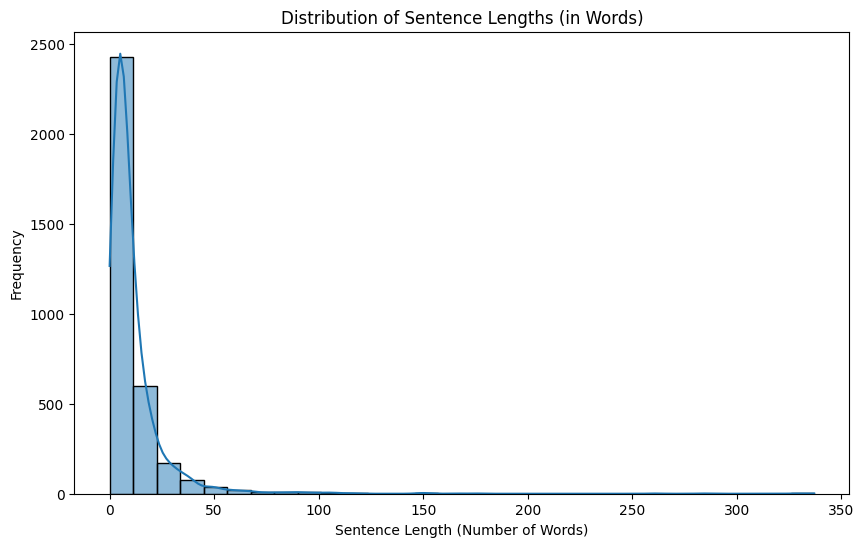

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

df_train['sentence_length'] = df_train['text'].apply(lambda x: len(x.split()))

# Plot the histogram of sentence lengths
plt.figure(figsize=(10, 6))
sns.histplot(df_train['sentence_length'], kde=True, bins=30)  # KDE for smoother curve
plt.title('Distribution of Sentence Lengths (in Words)')
plt.xlabel('Sentence Length (Number of Words)')
plt.ylabel('Frequency')
plt.show()

In [12]:
df_train_label_0 = df_train[df_train['label'] == 0]
df_train_label_1 = df_train[df_train['label'] == 1]

plt.figure(figsize=(12, 6))

# label 0
sns.histplot(df_train_label_0['sentence_length'], kde=True, bins=30, color='blue', label='Label 0', alpha=0.6)

# label 1
sns.histplot(df_train_label_1['sentence_length'], kde=True, bins=30, color='orange', label='Label 1', alpha=0.6)

plt.title('Sentence Length Distribution by Label (0 and 1)')
plt.xlabel('Sentence Length (Number of Words)')
plt.ylabel('Frequency')
plt.legend(title='Label')
plt.show()

NameError: name 'plt' is not defined

In [22]:
df_train

,text,label
2469,Nammude nattil oru arogyamandri undennu thonnu...,1
2614,ഈ അവസരത്തിൽ ഇതിന്റെ അനിവാര്യത അങ്ങേയറ്റമായിരുന...,1
1258,പാർട്ടിയുടെ പേരുകളിൽ മാത്രമേ മാറ്റമൊള്ളൂ...കാല...,1
2980,ഷാജഹാൻ നിനക്ക് തീരെ ബുദ്ധി ഇല്ലാതെ പോയി നിന്നെ...,0
2530,ഇതിനെതിരെ ഒരു പാർട്ടിയും മിണ്ടുന്നില്ലല്ലോ അവർ...,1
...,...,...
1600,ഈ പൊളിറ്റിക്കല്‍ ലീഡര്‍മാര്‍ക്ക് വരുന്ന covidന...,0
341,Kaaranabhoothan kollam,1
2380,എന്നാ...അനുഭവിച്ചോ,1
2573,"1023 പേർക് ഇതുവരെ രോഗം സ്ഥിതികരിച്ചു, ഇന്ത്യയി...",0


In [15]:
import torch
torch.cuda.empty_cache()
from transformers import Trainer, TrainingArguments
import torch
import numpy as np
from sklearn.metrics import f1_score, accuracy_score
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import XLMRobertaTokenizer, XLMRobertaForSequenceClassification
from transformers import AutoTokenizer, AutoModelForSequenceClassification

In [30]:
from transformers import Trainer, TrainingArguments
import torch
import numpy as np
from sklearn.metrics import f1_score, accuracy_score
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import XLMRobertaTokenizer, XLMRobertaForSequenceClassification
from transformers import AutoTokenizer, AutoModelForSequenceClassification
# Load tokenizer and model for sequence classification
#tokenizer = BertTokenizer.from_pretrained("google-bert/bert-base-multilingual-cased")
#model = BertForSequenceClassification.from_pretrained("google-bert/bert-base-multilingual-cased", num_labels=2)
#google/muril-base-cased
#tokenizer = BertTokenizer.from_pretrained("google/muril-base-cased")
#model = BertForSequenceClassification.from_pretrained("google/muril-base-cased", num_labels=2)
#tokenizer = XLMRobertaTokenizer.from_pretrained("xlm-roberta-base")
#model = XLMRobertaForSequenceClassification.from_pretrained("xlm-roberta-base", num_labels=2)
#ai4bharat/indic-bert
#tokenizer = AutoTokenizer.from_pretrained("ai4bharat/indic-bert")
#model = AutoModelForSequenceClassification.from_pretrained("ai4bharat/indic-bert", num_labels=2)
#malayalam Bert
tokenizer = AutoTokenizer.from_pretrained("l3cube-pune/malayalam-bert")
model = AutoModelForSequenceClassification.from_pretrained("l3cube-pune/malayalam-bert", num_labels=2)

tokenizer_config.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/3.16M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/6.41M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/664 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/951M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at l3cube-pune/malayalam-bert and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [17]:
class BertDataset:
    def __init__(self, text, tokenizer, max_len, target=None):
        self.text = text
        self.target = target
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.text)

    def __getitem__(self, idx):
        text = str(self.text[idx])
        inputs = self.tokenizer.encode_plus(
            text,
            None,
            add_special_tokens=True,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
        )

        ids = inputs["input_ids"]
        mask = inputs["attention_mask"]
        token_type_ids = inputs.get("token_type_ids", None)  # Handle models that may not use token_type_ids

        result = {
            "input_ids": torch.tensor(ids, dtype=torch.long),  # Use input_ids
            "attention_mask": torch.tensor(mask, dtype=torch.long),  # Use attention_mask
        }

        if token_type_ids is not None:
            result["token_type_ids"] = torch.tensor(token_type_ids, dtype=torch.long)

        if self.target is not None:
            result["labels"] = torch.tensor(self.target[idx], dtype=torch.long)  # Use labels instead of targets

        return result


In [27]:
#avg_len = np.mean(df_train['text'].apply(lambda x: len(x.split())))
#max_len = int(avg_len)  # Round to nearest integer if needed

In [18]:
max_len = 90  
train_dataset = BertDataset(df_train['text'].tolist(), tokenizer, max_len, df_train['label'].tolist())
dev_dataset = BertDataset(df_val['text'].tolist(), tokenizer, max_len, df_val['label'].tolist())
test_dataset = BertDataset(df_test['text'].tolist(), tokenizer, max_len)

In [19]:
from sklearn.metrics import f1_score, accuracy_score
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)  # Get predicted class indices
    f1 = f1_score(labels, predictions, average='macro')
    accuracy = accuracy_score(labels, predictions)
    
    return {
        'f1': f1,
        'accuracy': accuracy,
    }

In [20]:
import wandb
wandb.login(key='WANDB_API_KEY')

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: minhazulkabir (minhazulkabir-none). Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

**Malayalam Bert**

In [31]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir='./results',               # Save the final model here
    num_train_epochs=10,                   # Number of epochs
    per_device_train_batch_size=16,        # Batch size for training
    per_device_eval_batch_size=16,         # Batch size for evaluation
    logging_dir='./logs',                 # Logging directory (TensorBoard)
    logging_steps=500,                    # Log every 500 steps
    weight_decay=0.05,
    learning_rate=3e-5,
    #evaluation_strategy="epoch",          # Evaluate after each epoch
    save_strategy="no",               # Save after each epoch
    save_total_limit=1,                   # Keep only the last checkpoint
    load_best_model_at_end=True,          # Load best model based on evaluation metric
    metric_for_best_model='f1',           # Track F1 score for best model
    greater_is_better=True,               # Higher F1 is better
    gradient_accumulation_steps=1,
    report_to=None,                       # Disable reporting to external services like TensorBoard
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    compute_metrics=compute_metrics, 
)

trainer.train()
trainer.evaluate()


wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


Step,Training Loss
500,0.461700
1000,0.200200
1500,0.080300
2000,0.041600


{'eval_loss': 0.6239451766014099,
 'eval_f1': 0.8696366087110433,
 'eval_accuracy': 0.8696369636963697,
 'eval_runtime': 1.6141,
 'eval_samples_per_second': 375.447,
 'eval_steps_per_second': 23.543,
 'epoch': 10.0}

In [32]:
def make_test():
    #df_test = pd.read_csv('/kaggle/input/dataset/Fake_test_without_labels.csv')
    df_test['text'] = df_test['text'].apply(remove_emoji)
    df_test['text'] = df_test['text'].apply(remove_html)
    test_dataset = BertDataset(df_test['text'].tolist(), tokenizer, max_len)
    
    predictions = trainer.predict(test_dataset)
    predicted_labels = predictions.predictions.argmax(-1)
    df_test['Labels'] = predicted_labels
        
    csv_filename = 'prediction.csv'
    df_test.to_csv(csv_filename, index=False)
make_test()

In [33]:
def Testing():
    import pandas as pd
    from sklearn.metrics import f1_score
    
    predicted_df = pd.read_csv("/kaggle/working/prediction.csv")
    
    real_labels = real_df['label']
    predicted_labels = predicted_df['Labels']
    
    label_mapping = {'Fake': 0, 'original': 1}
    real_labels = real_labels.map(label_mapping)
    #predicted_labels = predicted_labels.map(label_mapping)
    
    real_labels = real_labels.to_numpy() if isinstance(real_labels, pd.Series) else real_labels
    predicted_labels = predicted_labels.to_numpy() if isinstance(predicted_labels, pd.Series) else predicted_labels
    
    f1 = f1_score(real_labels, predicted_labels, average='macro')
    
    print(f"F1 Score: {f1:.4f}")
Testing()

F1 Score: 0.8832


In [40]:
def save_best_model():
    import json
    from transformers import BertForSequenceClassification, BertTokenizer
    import os
    
    # Define your hyperparameters
    hyperparameters = {
        'model_name': 'xlmr',
        'T_sz': 0.15,
        'mx_len': 90,
        'b_sz': 16,
        'learning_rate': 3e-5,
        'num_train_epochs': 50,
        'batch_size': 16,
        'gradient_accumulation_steps': 1
    }
    
    # Create a directory to save the model and other artifacts
    output_dir = './best_model'
    os.makedirs(output_dir, exist_ok=True)
    
    # Save hyperparameters to a JSON file
    with open(os.path.join(output_dir, 'hyperparameters.json'), 'w') as f:
        json.dump(hyperparameters, f)
    
    # Save the model and tokenizer
    model.save_pretrained(output_dir)
    tokenizer.save_pretrained(output_dir)
    
    print(f"Model, tokenizer, and hyperparameters saved in {output_dir}")
save_best_model()

Model, tokenizer, and hyperparameters saved in ./best_model


In [25]:
import os
from huggingface_hub import login
def login_kaghub():
    login(token = "KAGGLE_TOKEN")#write_token
login_kaghub()
import wandb
wandb.login(key='WANDB_API_KEY')

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `huggingface-cli` if you want to set the git credential as well.
Token is valid (permission: write).
Your token has been saved to /root/.cache/huggingface/token
Login successful


True

In [43]:
from huggingface_hub import upload_folder

def upload_kaghub():
    repo_name = "R1FA7/Fake-Malayalam"  
    
    output_dir = './best_model'
    
    # Upload the model folder to Hugging Face Hub
    upload_folder(
        folder_path=output_dir, 
        path_in_repo=".",  
        repo_id=repo_name
    )
    
    print(f"Model, tokenizer, and hyperparameters have been successfully uploaded to Hugging Face Hub: {repo_name}")
upload_kaghub()

model.safetensors:   0%|          | 0.00/950M [00:00<?, ?B/s]

Model, tokenizer, and hyperparameters have been successfully uploaded to Hugging Face Hub: R1FA7/Fake-Malayalam


In [37]:
tests = pd.read_csv('/kaggle/working/prediction.csv')
tests

,Id,text,Labels
0,Fake_01,5000 ഉള്ള പോൾ ലോഗ്‌ഡ്‌വൻ ഇപ്പോള് 250000 എന്താ...,1
1,Fake_02,ഓഷോ രജനീഷ് പറഞ്ഞപോലെ എനിക്കപ്പോൾ തോന്നിയത് അ...,0
2,Fake_03,ചേട്ടാ വാർത്ത വയ്ക്കുന്നത് കേരളത്തിലാണ് സം...,0
3,Fake_04,Shame for entire Woman&#39;s of Kerala,1
4,Fake_05,135 code janaghal andhu wide business cheythal...,0
...,...,...,...
1014,Fake_1015,Correct ...China cheitha ...weapon spread ing ...,0
1015,Fake_1016,ഈ WHO പറയുന്നതനുസരിച്ചു ചികിത്സയും ലോക്ക് ഡൌൺ ...,0
1016,Fake_1017,Mask illa aarkum,1
1017,Fake_1018,ഇയാളെ കൊറോണ. രോഗി കൾ കിടയിൽ. ഇടാമായിരുന്നു---!!,0


In [38]:
tests['Labels'].value_counts()

Labels
1    519
0    500
Name: count, dtype: int64

In [20]:
real_df.head(2)

,text,label
0,5000 ഉള്ള പോൾ ലോഗ്‌ഡ്‌വൻ ഇപ്പോള് 250000 എന്താ...,Fake
1,ഓഷോ രജനീഷ് പറഞ്ഞപോലെ എനിക്കപ്പോൾ തോന്നിയത് അ...,Fake


**MalayalamBert, XLMR**

Processing model: R1FA7/Fake-Malayalam


tokenizer_config.json:   0%|          | 0.00/1.27k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/3.16M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/6.41M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/950M [00:00<?, ?B/s]

F1 Score: 0.8832
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.88      0.88       507
           1       0.88      0.89      0.88       512

    accuracy                           0.88      1019
   macro avg       0.88      0.88      0.88      1019
weighted avg       0.88      0.88      0.88      1019

Confusion Matrix:


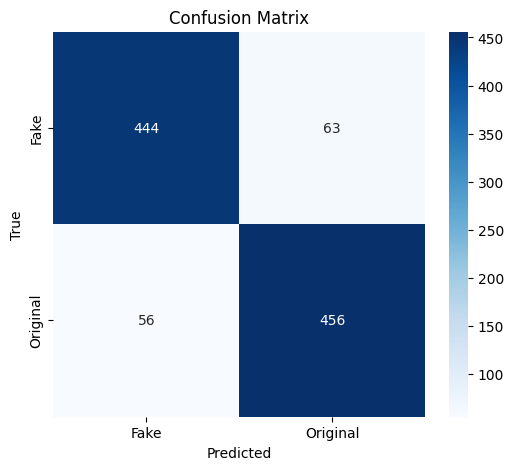

Processing model: R1FA7/Fake-XLMR


tokenizer_config.json:   0%|          | 0.00/1.17k [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/770 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

F1 Score: 0.8636
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       507
           1       0.86      0.87      0.86       512

    accuracy                           0.86      1019
   macro avg       0.86      0.86      0.86      1019
weighted avg       0.86      0.86      0.86      1019

Confusion Matrix:


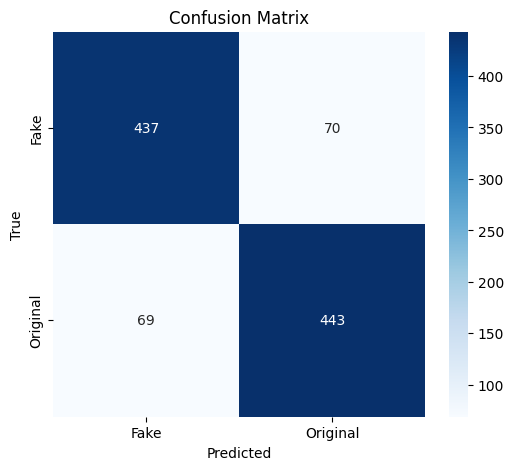

In [26]:
import json
import emoji
import re
import torch
import os  
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer
from transformers import TrainingArguments
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def remove_emoji(text):
    return emoji.replace_emoji(text, replace='')

def remove_html(text):
    return re.sub(r'<[^>]*>', '', text)

class BertDataset:
    def __init__(self, text, tokenizer, max_len):
        self.text = text
        self.tokenizer = tokenizer
        self.max_len = max_len
    
    def __len__(self):
        return len(self.text)
    
    def __getitem__(self, idx):
        text = str(self.text[idx])
        inputs = self.tokenizer.encode_plus(
            text,
            None,
            add_special_tokens=True,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
        )
    
        ids = inputs["input_ids"]
        mask = inputs["attention_mask"]
    
        result = {
            "input_ids": torch.tensor(ids, dtype=torch.long),
            "attention_mask": torch.tensor(mask, dtype=torch.long),
        }

        return result

def get_predictions_for_model(repo_name, max_len, real_df):
    # Load the model and tokenizer from Hugging Face Hub
    tokenizer = AutoTokenizer.from_pretrained(repo_name)
    model = AutoModelForSequenceClassification.from_pretrained(repo_name)

    # Preprocess the real_df (already containing text and labels)
    real_df['text'] = real_df['text'].apply(remove_emoji)
    real_df['text'] = real_df['text'].apply(remove_html)

    # Prepare dataset
    test_dataset = BertDataset(real_df['text'].tolist(), tokenizer, max_len)

    # Load training arguments 
    training_args = TrainingArguments(
        output_dir='./results',               
        num_train_epochs=10,     
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,  
        logging_dir='./logs',                
        logging_steps=500,
        weight_decay=0.05,
        learning_rate=3e-5,
        save_strategy="no",
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model='f1',
        greater_is_better=True,
        gradient_accumulation_steps=1,
        report_to=None,                       
    )

    # Initialize Trainer and make predictions
    trainer = Trainer(
        model=model,
        args=training_args,  # Use the same training arguments for all models
    )
    
    # Get the predictions
    predictions = trainer.predict(test_dataset)
    predicted_labels = predictions.predictions.argmax(-1)

    # Add predictions to DataFrame
    real_df['Labels'] = predicted_labels

    output_dir = '/kaggle/working'  # Root directory
    model_prediction_dir = os.path.join(output_dir, repo_name.split('/')[1])
    os.makedirs(model_prediction_dir, exist_ok=True)
    model_prediction_file = os.path.join(output_dir, f"{repo_name.split('/')[1]}.csv")

    # Save the predictions to the file
    real_df[['text', 'Labels']].to_csv(model_prediction_file, index=False)

    return real_df, predicted_labels

def calculate_metrics(real_df, predicted_labels):
    # Real labels
    real_labels = real_df['label'].map({'Fake': 0, 'original': 1})
    predicted_labels = real_df['Labels'].to_numpy()

    # F1 Score
    f1 = f1_score(real_labels, predicted_labels, average='macro')
    print(f"F1 Score: {f1:.4f}")

    # Classification Report
    print("Classification Report:")
    report = classification_report(real_labels, predicted_labels)
    print(report)

    # Confusion Matrix
    cm = confusion_matrix(real_labels, predicted_labels)
    print("Confusion Matrix:")
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Original'], yticklabels=['Fake', 'Original'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

def get_predictions_for_multiple_models():
    # Step 1: Load real labels (real_df) from file
    real_df = pd.read_csv('/kaggle/input/dataset/Fake_test_with_labels.csv')

    # Step 2: Define model repos and corresponding max_len values
    models_and_repos = [
        {"repo_name": "R1FA7/Fake-Malayalam", "max_len": 90},
        {"repo_name": "R1FA7/Fake-XLMR", "max_len": 90},
    ]

    # Process each model and get predictions
    for model_info in models_and_repos:
        print(f"Processing model: {model_info['repo_name']}")
        
        # Get predictions for the real_df with the corresponding max_len
        real_df, predicted_labels = get_predictions_for_model(
            model_info['repo_name'], model_info['max_len'], real_df
        )

        calculate_metrics(real_df, predicted_labels)
        
get_predictions_for_multiple_models()


**Majority Voting ensemble(Malayalam,XLMR,SarvamLLM)[PROPOSED]**

Macro F1 score: 0.8929989971455738

Classification Report:
              precision    recall  f1-score   support

        Fake       0.90      0.88      0.89       507
    original       0.88      0.91      0.89       512

    accuracy                           0.89      1019
   macro avg       0.89      0.89      0.89      1019
weighted avg       0.89      0.89      0.89      1019


Confusion Matrix:


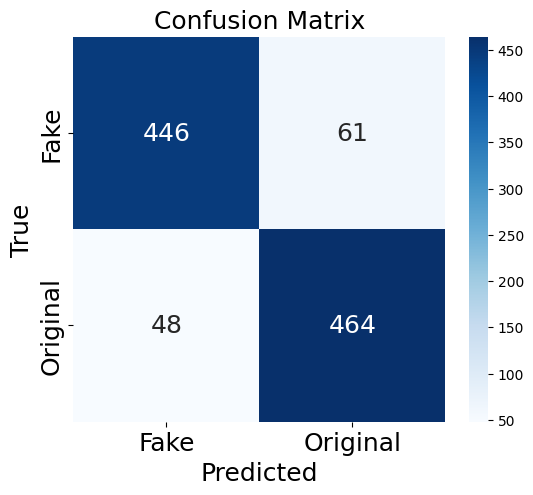

In [5]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

#Load predictions from all models and real labels
mal = pd.read_csv('/kaggle/working/Fake-Malayalam.csv')  # Malayalam BERT predictions
xlmr = pd.read_csv('/kaggle/working/Fake-XLMR.csv')  # XLM-R predictions
llm = pd.read_csv('/kaggle/input/llm-prediction/predictions (1).csv')  # LLM predictions
real = pd.read_csv('/kaggle/input/dataset/Fake_test_with_labels.csv')

#Extracting the labels from each model's predictions
mal_predictions = mal['Labels'].values
xlmr_predictions = xlmr['Labels'].values
llm_predictions = llm['Labels'].values
real_labels = real['label']  # True labels

#Majority Voting for Binary Classification
def majority_voting_binary(preds1, preds2, preds3):
    # Stack the predictions 
    stacked_preds = np.vstack([preds1, preds2, preds3])

    # Majority vote: for each sample, find the class with the most votes
    final_predictions = []
    for i in range(stacked_preds.shape[1]):  
        # Count the occurrence of each class (0 or 1) across the models
        unique, counts = np.unique(stacked_preds[:, i], return_counts=True)
        majority_class = unique[np.argmax(counts)]  # Class with the most votes
        final_predictions.append(majority_class)

    return np.array(final_predictions)

#majority voting to get the final ensemble predictions
ensemble_predictions = majority_voting_binary(mal_predictions, xlmr_predictions, llm_predictions)

# label mapping (0 -> 'Fake', 1 -> 'original')
reverse_label_mapping = {0: 'Fake', 1: 'original'}
ensemble_predictions_str = np.array([reverse_label_mapping[label] for label in ensemble_predictions])
real['Prediction'] = ensemble_predictions_str

label_mapping = {'Fake': 0, 'original': 1}
real_labels_numeric = real_labels.map(label_mapping)
macro_f1 = f1_score(real_labels_numeric, ensemble_predictions, average='macro')
print(f'Macro F1 score: {macro_f1}')

print("\nClassification Report:")
report = classification_report(real_labels_numeric, ensemble_predictions, target_names=['Fake', 'original'])
print(report)

cm = confusion_matrix(real_labels_numeric, ensemble_predictions)
print("\nConfusion Matrix:")
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Original'], yticklabels=['Fake', 'Original'], annot_kws={"size": 18})
plt.xlabel('Predicted', fontsize=18)
plt.ylabel('True', fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.title('Confusion Matrix',fontsize=18)
plt.show()


Macro F1 score: 0.8812543037237142

Classification Report:
              precision    recall  f1-score   support

        Fake       0.88      0.88      0.88       507
    original       0.88      0.88      0.88       512

    accuracy                           0.88      1019
   macro avg       0.88      0.88      0.88      1019
weighted avg       0.88      0.88      0.88      1019


Confusion Matrix:


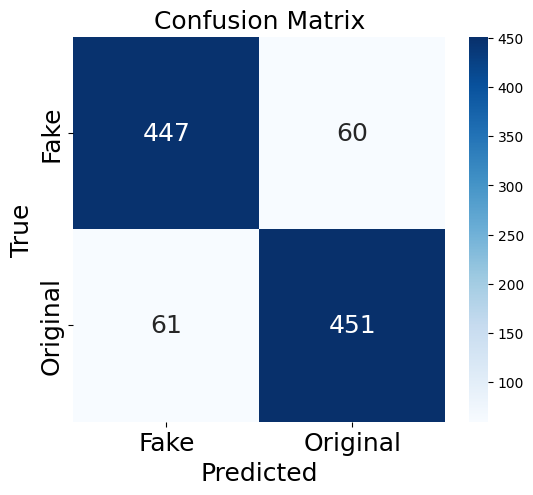

G-Mean score: 0.8813


In [34]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load predictions from all models and real labels
mal = pd.read_csv('/kaggle/working/Fake-Malayalam.csv')  # Malayalam BERT predictions
xlmr = pd.read_csv('/kaggle/working/Fake-XLMR.csv')  # XLM-R predictions
#llm = pd.read_csv('/kaggle/input/llm-prediction/predictions (1).csv')  # LLM predictions
llm = pd.read_csv('/kaggle/working/Fake-Distil-Bert.csv')
real = pd.read_csv('/kaggle/input/dataset/Fake_test_with_labels.csv')

# Extracting the labels from each model's predictions
mal_predictions = mal['Labels'].values
xlmr_predictions = xlmr['Labels'].values
llm_predictions = llm['Labels'].values
real_labels = real['label']  # True labels

#Implement Majority Voting for Binary Classification
def majority_voting_binary(preds1, preds2, preds3):
    """
    Perform majority voting for binary classification (0 or 1).
    Returns the majority-voted class (0 or 1).
    """
    # Stack the predictions from the three models
    stacked_preds = np.vstack([preds1, preds2, preds3])

    # Majority vote: for each sample, find the class with the most votes
    final_predictions = []
    for i in range(stacked_preds.shape[1]):  # Iterate over each sample
        # Count the occurrence of each class (0 or 1) across the models
        unique, counts = np.unique(stacked_preds[:, i], return_counts=True)
        majority_class = unique[np.argmax(counts)]  # Class with the most votes
        final_predictions.append(majority_class)

    return np.array(final_predictions)

#Perform majority voting to get the final ensemble predictions
ensemble_predictions = majority_voting_binary(mal_predictions, xlmr_predictions, llm_predictions)

# Reverse the label mapping (0 -> 'Fake', 1 -> 'original')
reverse_label_mapping = {0: 'Fake', 1: 'original'}
ensemble_predictions_str = np.array([reverse_label_mapping[label] for label in ensemble_predictions])
real['Prediction'] = ensemble_predictions_str

# Calculate the macro F1 score between ensemble predictions and real labels
label_mapping = {'Fake': 0, 'original': 1}
real_labels_numeric = real_labels.map(label_mapping)
macro_f1 = f1_score(real_labels_numeric, ensemble_predictions, average='macro')
print(f'Macro F1 score: {macro_f1}')

# Classification Report
print("\nClassification Report:")
report = classification_report(real_labels_numeric, ensemble_predictions, target_names=['Fake', 'original'])
print(report)

# Confusion Matrix
cm = confusion_matrix(real_labels_numeric, ensemble_predictions)
print("\nConfusion Matrix:")
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Original'], yticklabels=['Fake', 'Original'], annot_kws={"size": 18})
plt.xlabel('Predicted', fontsize=18)
plt.ylabel('True', fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.title('Confusion Matrix', fontsize=18)
plt.show()

# Calculate G-Mean Score
# Extract TP, TN, FP, FN from the confusion matrix
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Calculate True Positive Rate (TPR) and True Negative Rate (TNR)
TPR = TP / (TP + FN)  # Sensitivity / Recall
TNR = TN / (TN + FP)  # Specificity

# Calculate G-Mean
G_mean = np.sqrt(TPR * TNR)
print(f'G-Mean score: {G_mean:.4f}')


**other ensemble techniques**

In [11]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# Stack predictions from the models as features
stacked_features = np.vstack([mal_predictions, xlmr_predictions, llm_predictions]).T

# Train AdaBoost on the base predictions
base_model = DecisionTreeClassifier(max_depth=1)  # Weak learner
boosting_model = AdaBoostClassifier(base_model, n_estimators=5000)
boosting_model.fit(stacked_features, real_labels_numeric)

# Make predictions
ensemble_predictions_boosted = boosting_model.predict(stacked_features)

# Calculate Macro F1 score
macro_f1_boosted = f1_score(real_labels_numeric, ensemble_predictions_boosted, average='macro')
print(f'Macro F1 score (Boosting): {macro_f1_boosted}')


Macro F1 score (Boosting): 0.8929989971455738


In [13]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

# Stack predictions from the models as features
stacked_features = np.vstack([mal_predictions, xlmr_predictions, llm_predictions]).T

# Train a Bagging model on the base predictions
bagging_model = BaggingClassifier(base_estimator=DecisionTreeClassifier(), n_estimators=5000, random_state=42)
bagging_model.fit(stacked_features, real_labels_numeric)

# Make predictions
ensemble_predictions_bagging = bagging_model.predict(stacked_features)

# Calculate Macro F1 score
macro_f1_bagging = f1_score(real_labels_numeric, ensemble_predictions_bagging, average='macro')
print(f'Macro F1 score (Bagging): {macro_f1_bagging}')


Macro F1 score (Bagging): 0.8929989971455738


In [14]:
def threshold_voting(preds1, preds2, preds3, threshold=0.6):
    stacked_preds = np.vstack([preds1, preds2, preds3])
    final_predictions = []
    for i in range(stacked_preds.shape[1]):
        # Check how many models predict '1' (original) and how confident they are
        if np.mean(stacked_preds[:, i] == 1) >= threshold:
            final_predictions.append(1)  # Predict 'original'
        else:
            final_predictions.append(0)  # Predict 'fake'
    return np.array(final_predictions)

ensemble_predictions_threshold = threshold_voting(mal_predictions, xlmr_predictions, llm_predictions)

# Calculate Macro F1 score
macro_f1_threshold = f1_score(real_labels_numeric, ensemble_predictions_threshold, average='macro')
print(f'Macro F1 score (Threshold Voting): {macro_f1_threshold}')


Macro F1 score (Threshold Voting): 0.8929989971455738


**Error Analysis**

In [64]:
#acual label and predicted label
real[['text', 'label', 'Prediction']].sample(10)

,text,label,Prediction
970,Ithu BBcyilum New york Timesilum vanno??,original,Fake
686,ഏറ്റവും വെറുക്കപ്പെട്ട ഭരണം,original,original
662,നിങ്ങൾക്ക് സിപിഎമ്മിനെ പറ്റി ഒരു ചുക്കും അറിയില്ല,original,original
524,da kayuthe 2 aaycha aayalloda nee enthe vartha...,Fake,Fake
310,Deltaum inde omicronum inde education illatha ...,original,original
64,Panna rascal paranaari...,original,original
345,ചൈനയിൽ നിന്നാണല്ലോ ആദ്യം തുടങ്ങിയത് ... but ഇപ...,Fake,Fake
861,എല്ലാവരും കേക്കുന്നുണ്ടല്ലോ അല്ലേ..........,Fake,original
607,Pig thayolikal,Fake,original
559,🐒 nde kayille pooooo mala👀,original,original


In [6]:
dy = real[real['label']==real['Prediction']]
k=dy[dy['label']=='original']
k['text'].apply(lambda x: len(x.split())).mean()

8.407327586206897

In [19]:
dy.sample(10)

,text,label,Prediction
327,നീ പുലിയാണ് കേട്ടോ,original,original
919,നാറിയ പരനാറിയും അവന്റെ മരുമകനും കൂടെ നശിപ്പിക്...,original,original
117,നേതാവിന്റെ അപ്പി തിന്നു ജീവിക്കുന്നവർ ആ അപ്പി ...,original,original
25,എല്ലാം വരുടെയും പ്രാത്ഥന മൂലം ആണ്,Fake,Fake
505,When idiots rule the state this is what happens.,original,original
495,Corona ye jesus oddikkum,Fake,Fake
953,കഷ്ടം ഈ പെണ്ണുങ്ങൾക്ക് ഇപ്പഴും തലക്ക് ...,original,original
1,ഓഷോ രജനീഷ് പറഞ്ഞപോലെ എനിക്കപ്പോൾ തോന്നിയത് അ...,Fake,Fake
729,കുംഭ kovid രാജ്യ ദ്രോ ഹം,Fake,Fake
706,CPM NO PROBLEM,original,original


In [14]:
dx  = real[real['label']!=real['Prediction']]
dx.sample(10)

,text,label,Prediction
732,ഇന്നെങ്കിലും ആ കണ്ണട മുഖത്ത് വെക്കും എന്ന് കരു...,Fake,original
74,Ivareyokke jeyipichavare sammadikkanam🤐,original,Fake
43,Ede sagavu endina epo America poyadu keraliti...,original,Fake
777,കോവിസിന് മതം ജാതി വർഗ്ഗം ഒന്നും ഇല്ലന്ന് ഭരണധി...,Fake,original
615,Arenkilum pedippicho🤔🤔🤔,Fake,original
666,The prostutter cahanal?,Fake,original
284,Really great,original,Fake
455,അങ്ങനെ വരട്ടെ!,original,Fake
877,"കൊറോണ കച്ചവടം ചാനലുകാർ നന്നായി ആഘോഷിച്ചു,epol ...",Fake,original
83,Super,original,Fake


In [15]:
x = df_train1[df_train1['label']=='Fake']
x['text'].apply(lambda x: len(x.split())).mean()

14.507817385866167

In [44]:
x.sample(10)

,text,label
1399,Ivar parayunnath sheriyanonu onnu nokkikoode o...,Fake
46,ഹായ് സർ.,Fake
2482,WHO ennaundakan anno irukunaa china edhira oru...,Fake
908,"അന്തം ഇല്ലാത്തവരാ, മാധ്യമങ്ങൾ",Fake
3028,They achieved Herd immunity .....,Fake
3239,It&#39;s not like India as an open book but ne...,Fake
2500,എല്ലാ രാജ്യങ്ങളും ചേർന്ന് ചൈനക്ക് ഒരു നല്ല പണി...,Fake
987,<br>അമേരിക്ക വേണ്ടേ ലോകത്തോട് ആദ്യം കുറ്റം യേറ...,Fake
2530,Aara ee jacob vadakanchery??..enthaanu avare y...,Fake
3130,Pukachu purathuchadickuka,Fake


In [16]:
originalError = dx[dx['label']=='original']
print(originalError['text'].apply(lambda x: len(x.split())).mean())
originalError.sample(10)

8.854166666666666


,text,label,Prediction
74,Ivareyokke jeyipichavare sammadikkanam🤐,original,Fake
31,"Communists 😜 have to wear mask , why to enjoy ...",original,Fake
303,"Parayunnath onne, cheyuunath veronne.. nalla b...",original,Fake
284,Really great,original,Fake
808,വാക്‌സിൻ എന്തിനാണ്?,original,Fake
387,"&quot;എന്റെ തല, എന്റെ ഫുൾ ഫിഗർ &quot; എന്ന തര...",original,Fake
848,അതിനെന്താ? 150 എന്നതിലെ &quot; 1 &quot;<br>പൂജ...,original,Fake
358,1947 ഓഗസ്റ്റ് 15 ന് ഇന്ത്യക്ക് സ്വാതന്ത്ര്യം ക...,original,Fake
748,ഇതൊക്കെ കാണുമ്പോൾ കാലം കാത്തു വെച്ച നിധിയാണെൻ ...,original,Fake
229,നല്ല സോഷ്യൽ distancing ആണല്ലോ 😶🤷‍♀️,original,Fake


In [17]:
fakeError = dx[dx['label']=='Fake']
print(fakeError['text'].apply(lambda x: len(x.split())).mean())
fakeError.sample(10)


7.770491803278689


,text,label,Prediction
526,നശിപ്പിച്ചു കളയണം ഈ കമ്മ്യുണിസ്റ്റ് രാജ്യത്തെ,Fake,original
287,Nammada nattil evida kantathe vidheshathuninnu...,Fake,original
774,നശിക്കട്ടെ സർ എല്ലാം... കഷ്ട്ടം...,Fake,original
359,പൊട്ടൻ...,Fake,original
242,GOMUTHRUM CHAI NAKU MODI KODUTHU VITIR...,Fake,original
604,Ivar...rajyadrohikal..ennu...ethra...pravasyam...,Fake,original
72,കൊറോണ സിപിഎം നേയും dyfi. യേയും ഭയക്കുന്നു. ബക്...,Fake,original
454,മാസ്ക് താഴെ കെട്ടി വരുന്നവരെ വിവരം ഇല്ലാത്തവർ ...,Fake,original
477,Pravasikal ano koronakkar...,Fake,original
861,എല്ലാവരും കേക്കുന്നുണ്ടല്ലോ അല്ലേ..........,Fake,original


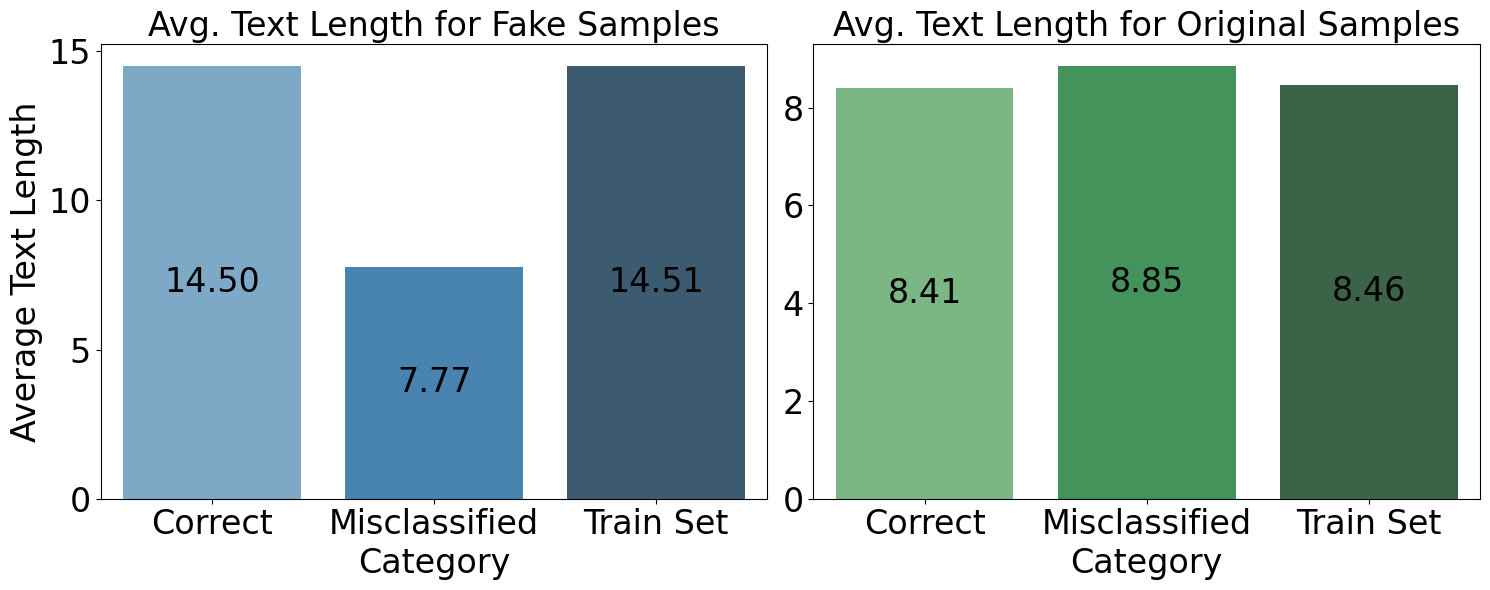

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Calculate Average Length for Correctly Classified "Fake"
correct_fake = dy[(dy['label'] == 'Fake') & (dy['label'] == dy['Prediction'])]
avg_len_correct_fake = correct_fake['text'].apply(lambda x: len(x.split())).mean()

# 2. Calculate Average Length for Misclassified "Fake"
misclassified_fake = dx[(dx['label'] == 'Fake')]
avg_len_misclassified_fake = misclassified_fake['text'].apply(lambda x: len(x.split())).mean()

# 3. Calculate Average Length for All "Fake" in Training Set
train_fake = df_train1[df_train1['label'] == 'Fake']
avg_len_all_fake = train_fake['text'].apply(lambda x: len(x.split())).mean()

# Prepare Data for Plotting for "Fake"
data_fake = {
    'Category': ['Correct', 'Misclassified', 'Train Set'],
    'Average Text Length': [avg_len_correct_fake, avg_len_misclassified_fake, avg_len_all_fake]
}

# Convert to DataFrame
df_plot_fake = pd.DataFrame(data_fake)

# 4. Calculate Average Length for Correctly Classified "Original"
correct_original = dy[(dy['label'] == 'original') & (dy['label'] == dy['Prediction'])]
avg_len_correct_original = correct_original['text'].apply(lambda x: len(x.split())).mean()

# 5. Calculate Average Length for Misclassified "Original"
misclassified_original = dx[(dx['label'] == 'original')]
avg_len_misclassified_original = misclassified_original['text'].apply(lambda x: len(x.split())).mean()

# 6. Calculate Average Length for All "Original" in Training Set
train_original = df_train1[df_train1['label'] == 'original']
avg_len_all_original = train_original['text'].apply(lambda x: len(x.split())).mean()

# Prepare Data for Plotting for "Original"
data_original = {
    'Category': ['Correct', 'Misclassified', 'Train Set'],
    'Average Text Length': [avg_len_correct_original, avg_len_misclassified_original, avg_len_all_original]
}

# Convert to DataFrame
df_plot_original = pd.DataFrame(data_original)

# Create side-by-side bar charts
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot for "Fake"
sns.barplot(x='Category', y='Average Text Length', data=df_plot_fake, palette='Blues_d', ax=axes[0])
axes[0].set_title('Avg. Text Length for Fake Samples', fontsize=24)
axes[0].set_xlabel('Category', fontsize=24)
axes[0].set_ylabel('Average Text Length', fontsize=24)

# Adding value labels inside the bars in the "Fake" plot
for p in axes[0].patches:
    height = p.get_height()
    axes[0].annotate(f'{height:.2f}', 
                     (p.get_x() + p.get_width() / 2., height / 2),  # Inside the bar
                     ha='center', va='center', 
                     fontsize=24, color='black')

# Plot for "Original"
sns.barplot(x='Category', y='Average Text Length', data=df_plot_original, palette='Greens_d', ax=axes[1])
axes[1].set_title('Avg. Text Length for Original Samples', fontsize=24)
axes[1].set_xlabel('Category', fontsize=24)
axes[1].set_ylabel('')  # Remove the y-axis label from the second plot

# Adding value labels inside the bars in the "Original" plot
for p in axes[1].patches:
    height = p.get_height()
    axes[1].annotate(f'{height:.2f}', 
                     (p.get_x() + p.get_width() / 2., height / 2),  # Inside the bar
                     ha='center', va='center', 
                     fontsize=24, color='black')

# Increase font size for category (x-axis) labels
axes[0].tick_params(axis='x', labelsize=24)
axes[1].tick_params(axis='x', labelsize=24)

# Increase font size for y-axis labels and ticks
axes[0].tick_params(axis='y', labelsize=24)
axes[1].tick_params(axis='y', labelsize=24)

# Display the plot
plt.tight_layout()
plt.show()


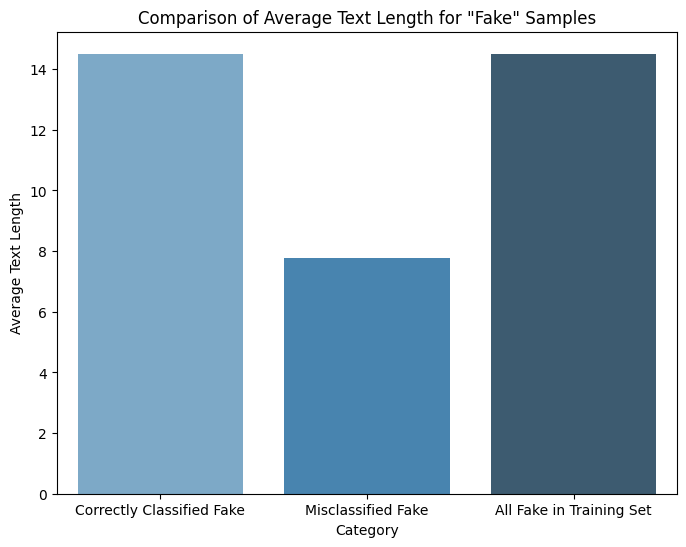

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate Average Length for Correctly Classified "Fake"
correct_fake = dy[(dy['label'] == 'Fake') & (dy['label'] == dy['Prediction'])]
avg_len_correct_fake = correct_fake['text'].apply(lambda x: len(x.split())).mean()

# 2. Calculate Average Length for Misclassified "Fake"
misclassified_fake = dx[(dx['label'] == 'Fake')]
avg_len_misclassified_fake = misclassified_fake['text'].apply(lambda x: len(x.split())).mean()

# 3. Calculate Average Length for All "Fake" in Training Set
train_fake = x  # Assuming 'x' contains all the "Fake" samples in the training set
avg_len_all_fake = train_fake['text'].apply(lambda x: len(x.split())).mean()

# Prepare Data for Plotting
data = {
    'Category': ['Correctly Classified Fake', 'Misclassified Fake', 'All Fake in Training Set'],
    'Average Text Length': [avg_len_correct_fake, avg_len_misclassified_fake, avg_len_all_fake]
}

# Convert to DataFrame
df_plot = pd.DataFrame(data)

# Plot the Bar Chart
plt.figure(figsize=(8, 6))
sns.barplot(x='Category', y='Average Text Length', data=df_plot, palette='Blues_d')
plt.title('Comparison of Average Text Length for "Fake" Samples')
plt.xlabel('Category')
plt.ylabel('Average Text Length')
plt.show()


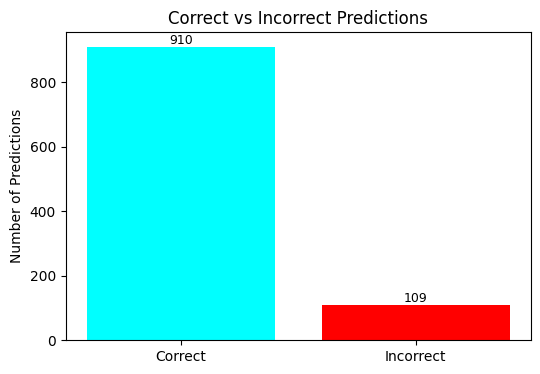

In [115]:
#correct and incorrect predictions
correct_preds = np.sum(ensemble_predictions == real_labels_numeric)
incorrect_preds = len(real_labels_numeric) - correct_preds

# Plotting the bar chart
labels = ['Correct', 'Incorrect']
values = [correct_preds, incorrect_preds]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['cyan', 'red'])

# Add numbers on top of the bars
for bar in bars:
    yval = bar.get_height()  # Get the height (number of predictions)
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 1,  # Position the text
             str(int(yval)), ha='center', va='bottom',  # Display the number
             fontsize=9, color='black')

plt.title('Correct vs Incorrect Predictions')
plt.ylabel('Number of Predictions')
plt.show()


In [ ]:
#RENAME
# Drop the 'text' column and keep only 'Id' and 'Labels' columns
mal_cleaned = mal[['Id', 'Labels']]

# Map 0 to 'Fake' and 1 to 'original' in the 'Labels' column
mal_cleaned['Labels'] = mal_cleaned['Labels'].map({0: 'Fake', 1: 'original'})

# Save the cleaned dataframe as a new CSV file with the specified name
mal_cleaned.to_csv('/content/CUET-NLP_MP_Malayalam_task1_run2.csv', index=False)
print("File saved as 'CUET-NLP_MP_Malayalam_task1_run2.csv'.")


In [ ]:
#RENAME
# Drop the 'text' column and keep only 'Id' and 'Labels' columns
llm_cleaned = llm[['Id', 'Labels']]

# Map 0 to 'Fake' and 1 to 'original' in the 'Labels' column
llm_cleaned['Labels'] =llm_cleaned['Labels'].map({0: 'Fake', 1: 'original'})

# Save the cleaned dataframe as a new CSV file with the specified name
llm_cleaned.to_csv('/content/CUET-NLP_MP_Malayalam_task1_run3.csv', index=False)
print("File saved as 'CUET-NLP_MP_Malayalam_task1_run3.csv'.")


In [ ]:
#TEST FINAL
import pandas as pd
from sklearn.metrics import f1_score

# Step 1: Load the predictions file and real labels
predictions_df = pd.read_csv('/content/CUET-NLP_MP_Malayalam_task1_run1.csv')
real_df = pd.read_csv('/content/Fake_test_with_labels.csv')

# Step 2: Map the Labels from 'Fake', 'original' to 0 and 1 in the predicted dataframe
predictions_df['Labels'] = predictions_df['Labels'].map({'Fake': 0, 'original': 1})

# Step 3: Map the real labels from 'Fake', 'original' to 0 and 1
real_labels = real_df['label'].map({'Fake': 0, 'original': 1})

# Step 4: Calculate the Macro F1 score
f1 = f1_score(real_labels, predictions_df['Labels'], average='macro')

print(f'Macro F1 score: {f1}')


**IndicSBert**

In [84]:
tokenizer = BertTokenizer.from_pretrained("l3cube-pune/indic-sentence-bert-nli")
model = BertForSequenceClassification.from_pretrained("l3cube-pune/indic-sentence-bert-nli", num_labels=2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at l3cube-pune/indic-sentence-bert-nli and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [85]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir='./results',               # Save the final model here
    num_train_epochs=10,                   # Number of epochs
    per_device_train_batch_size=16,        # Batch size for training
    per_device_eval_batch_size=16,         # Batch size for evaluation
    logging_dir='./logs',                 # Logging directory (TensorBoard)
    logging_steps=500,                    # Log every 500 steps
    weight_decay=0.05,
    learning_rate=3e-5,
    #evaluation_strategy="epoch",          # Evaluate after each epoch
    save_strategy="no",               # Save after each epoch
    save_total_limit=1,                   # Keep only the last checkpoint
    load_best_model_at_end=True,          # Load best model based on evaluation metric
    metric_for_best_model='f1',           # Track F1 score for best model
    greater_is_better=True,               # Higher F1 is better
    gradient_accumulation_steps=1,
    report_to=None,                       # Disable reporting to external services like TensorBoard
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    compute_metrics=compute_metrics, 
)

trainer.train()
trainer.evaluate()


Step,Training Loss
500,0.418100
1000,0.165800
1500,0.066700
2000,0.035200


{'eval_loss': 0.6598962545394897,
 'eval_f1': 0.870615040274483,
 'eval_accuracy': 0.8707037643207856,
 'eval_runtime': 1.8591,
 'eval_samples_per_second': 328.648,
 'eval_steps_per_second': 20.978,
 'epoch': 10.0}

F1 Score: 0.8685

Classification Report:
              precision    recall  f1-score   support

        Fake       0.87      0.87      0.87       507
    original       0.87      0.87      0.87       512

    accuracy                           0.87      1019
   macro avg       0.87      0.87      0.87      1019
weighted avg       0.87      0.87      0.87      1019


Confusion Matrix:
[[441  66]
 [ 68 444]]


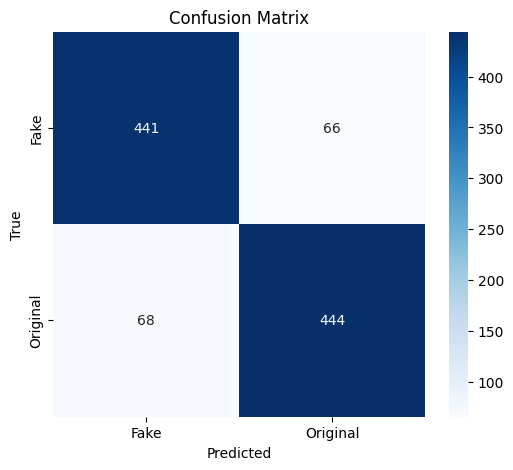

In [86]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df_test' contains the predictions and 'real_df' contains the real labels
real_df = pd.read_csv('/kaggle/input/dataset/Fake_test_with_labels.csv')  # Real labels
predictions = trainer.predict(test_dataset)
predicted_labels = predictions.predictions.argmax(-1)
df_test['Labels'] = predicted_labels
predicted_labels = df_test['Labels'].to_numpy()  # Actual predicted labels

real_labels = real_df['label'].map({'Fake': 0, 'original': 1}).to_numpy()

# Step 1: Calculate F1 Score (Macro)
f1 = f1_score(real_labels, predicted_labels, average='macro')
print(f"F1 Score: {f1:.4f}")

# Step 2: Generate Classification Report
print("\nClassification Report:")
report = classification_report(real_labels, predicted_labels, target_names=['Fake', 'original'])
print(report)

# Step 3: Compute and Plot Confusion Matrix
cm = confusion_matrix(real_labels, predicted_labels)
print("\nConfusion Matrix:")
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Original'], yticklabels=['Fake', 'Original'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


**mBert**

In [16]:
tokenizer = BertTokenizer.from_pretrained("google-bert/bert-base-multilingual-cased")
model = BertForSequenceClassification.from_pretrained("google-bert/bert-base-multilingual-cased", num_labels=2)


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google-bert/bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [21]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir='./results',               # Save the final model here
    num_train_epochs=10,                   # Number of epochs
    per_device_train_batch_size=16,        # Batch size for training
    per_device_eval_batch_size=16,         # Batch size for evaluation
    logging_dir='./logs',                 # Logging directory (TensorBoard)
    logging_steps=500,                    # Log every 500 steps
    weight_decay=0.05,
    learning_rate=3e-5,
    #evaluation_strategy="epoch",          # Evaluate after each epoch
    save_strategy="no",               # Save after each epoch
    save_total_limit=1,                   # Keep only the last checkpoint
    load_best_model_at_end=True,          # Load best model based on evaluation metric
    metric_for_best_model='f1',           # Track F1 score for best model
    greater_is_better=True,               # Higher F1 is better
    gradient_accumulation_steps=1,
    report_to=None,                       # Disable reporting to external services like TensorBoard
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    compute_metrics=compute_metrics, 
)

trainer.train()
trainer.evaluate()


wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


Step,Training Loss
500,0.432100
1000,0.187800
1500,0.061200
2000,0.028200


{'eval_loss': 1.0099040269851685,
 'eval_f1': 0.8481252656009937,
 'eval_accuracy': 0.8481848184818482,
 'eval_runtime': 1.9315,
 'eval_samples_per_second': 313.742,
 'eval_steps_per_second': 19.674,
 'epoch': 10.0}

F1 Score: 0.8459

Classification Report:
              precision    recall  f1-score   support

        Fake       0.85      0.84      0.84       507
    original       0.84      0.85      0.85       512

    accuracy                           0.85      1019
   macro avg       0.85      0.85      0.85      1019
weighted avg       0.85      0.85      0.85      1019


Confusion Matrix:


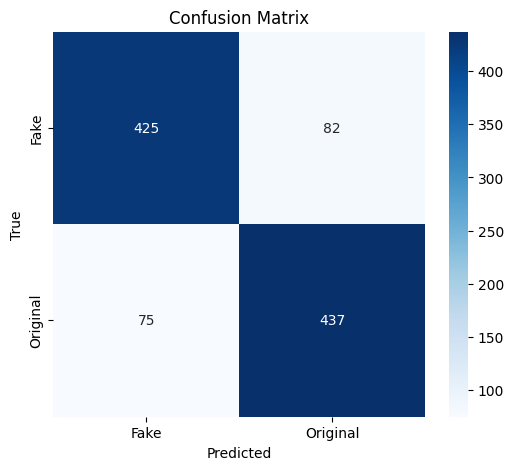

Predictions saved to 'predictions_output.csv'.


In [23]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df_test' contains the predictions and 'real_df' contains the real labels
real_df = pd.read_csv('/kaggle/input/dataset/Fake_test_with_labels.csv')  # Real labels
predictions = trainer.predict(test_dataset)  # Prediction from model
predicted_labels = predictions.predictions.argmax(-1)
df_test['Labels'] = predicted_labels

predicted_labels = df_test['Labels'].to_numpy()  # Actual predicted labels

# Mapping the real labels to numeric values (0 -> 'Fake', 1 -> 'original')
real_labels = real_df['label'].map({'Fake': 0, 'original': 1}).to_numpy()

# Step 1: Calculate F1 Score (Macro)
f1 = f1_score(real_labels, predicted_labels, average='macro')
print(f"F1 Score: {f1:.4f}")

# Step 2: Generate Classification Report
print("\nClassification Report:")
report = classification_report(real_labels, predicted_labels, target_names=['Fake', 'original'])
print(report)

# Step 3: Compute and Plot Confusion Matrix
cm = confusion_matrix(real_labels, predicted_labels)
print("\nConfusion Matrix:")
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Original'], yticklabels=['Fake', 'Original'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Step 4: Save predictions to CSV
# Assuming df_test contains a unique 'id' column for each text sample
# Save the 'id' and the 'Labels' (predictions) to a CSV file

output_df = df_test[['text', 'Labels']]  # Adjust 'id' column if your dataframe has a different unique identifier
#output_df['Labels'] = output_df['Labels'].map({0: 'Fake', 1: 'original'})  # Reverse mapping to 'Fake'/'original'

# Save to CSV
output_df.to_csv('Fake-mBERT.csv', index=False)
print("Predictions saved to 'predictions_output.csv'.")


F1 Score: 0.8527

Classification Report:
              precision    recall  f1-score   support

        Fake       0.87      0.83      0.85       507
    original       0.84      0.87      0.86       512

    accuracy                           0.85      1019
   macro avg       0.85      0.85      0.85      1019
weighted avg       0.85      0.85      0.85      1019


Confusion Matrix:
[[423  84]
 [ 66 446]]


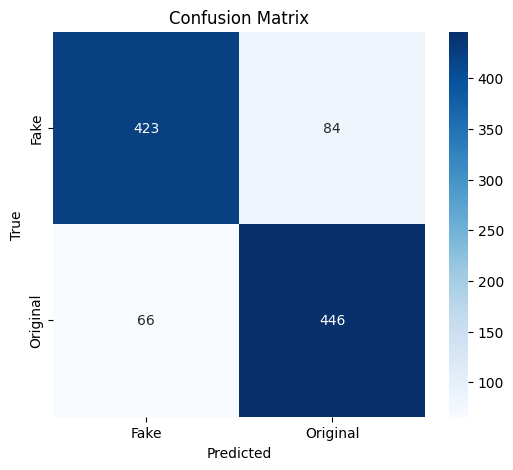

In [99]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df_test' contains the predictions and 'real_df' contains the real labels
real_df = pd.read_csv('/kaggle/input/dataset/Fake_test_with_labels.csv')  # Real labels
predictions = trainer.predict(test_dataset)
predicted_labels = predictions.predictions.argmax(-1)
df_test['Labels'] = predicted_labels

predicted_labels = df_test['Labels'].to_numpy()  # Actual predicted labels

# Mapping the real labels to numeric values (0 -> 'Fake', 1 -> 'original')
real_labels = real_df['label'].map({'Fake': 0, 'original': 1}).to_numpy()

# Step 1: Calculate F1 Score (Macro)
f1 = f1_score(real_labels, predicted_labels, average='macro')
print(f"F1 Score: {f1:.4f}")

# Step 2: Generate Classification Report
print("\nClassification Report:")
report = classification_report(real_labels, predicted_labels, target_names=['Fake', 'original'])
print(report)

# Step 3: Compute and Plot Confusion Matrix
cm = confusion_matrix(real_labels, predicted_labels)
print("\nConfusion Matrix:")
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Original'], yticklabels=['Fake', 'Original'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


**DistilBert**

In [30]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

# Load the DistilBERT tokenizer and model
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-multilingual-cased")
model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-multilingual-cased", num_labels=2)


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [31]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir='./results',               # Save the final model here
    num_train_epochs=10,                   # Number of epochs
    per_device_train_batch_size=16,        # Batch size for training
    per_device_eval_batch_size=16,         # Batch size for evaluation
    logging_dir='./logs',                 # Logging directory (TensorBoard)
    logging_steps=500,                    # Log every 500 steps
    weight_decay=0.05,
    learning_rate=3e-5,
    #evaluation_strategy="epoch",          # Evaluate after each epoch
    save_strategy="no",               # Save after each epoch
    save_total_limit=1,                   # Keep only the last checkpoint
    load_best_model_at_end=True,          # Load best model based on evaluation metric
    metric_for_best_model='f1',           # Track F1 score for best model
    greater_is_better=True,               # Higher F1 is better
    gradient_accumulation_steps=1,
    report_to=None,                       # Disable reporting to external services like TensorBoard
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    compute_metrics=compute_metrics, 
)

trainer.train()
trainer.evaluate()


Step,Training Loss
500,0.426500
1000,0.153400
1500,0.048700
2000,0.015800


{'eval_loss': 1.2112411260604858,
 'eval_f1': 0.8201197676540191,
 'eval_accuracy': 0.8201320132013201,
 'eval_runtime': 1.1813,
 'eval_samples_per_second': 513.001,
 'eval_steps_per_second': 32.168,
 'epoch': 10.0}

F1 Score: 0.8361

Classification Report:
              precision    recall  f1-score   support

        Fake       0.82      0.85      0.84       507
    original       0.85      0.82      0.83       512

    accuracy                           0.84      1019
   macro avg       0.84      0.84      0.84      1019
weighted avg       0.84      0.84      0.84      1019


Confusion Matrix:


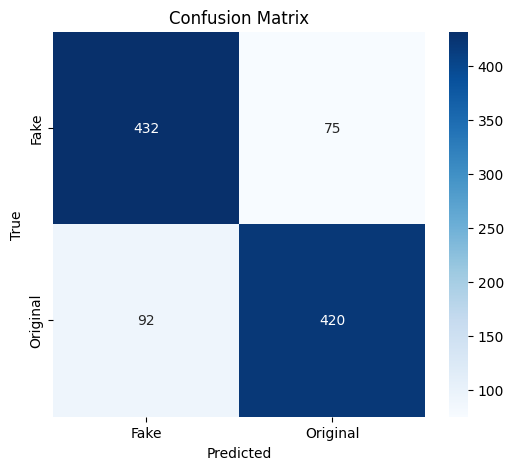

Predictions saved to 'predictions_output.csv'.


In [32]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df_test' contains the predictions and 'real_df' contains the real labels
real_df = pd.read_csv('/kaggle/input/dataset/Fake_test_with_labels.csv')  # Real labels
predictions = trainer.predict(test_dataset)  # Prediction from model
predicted_labels = predictions.predictions.argmax(-1)
df_test['Labels'] = predicted_labels

predicted_labels = df_test['Labels'].to_numpy()  # Actual predicted labels

# Mapping the real labels to numeric values (0 -> 'Fake', 1 -> 'original')
real_labels = real_df['label'].map({'Fake': 0, 'original': 1}).to_numpy()

# Step 1: Calculate F1 Score (Macro)
f1 = f1_score(real_labels, predicted_labels, average='macro')
print(f"F1 Score: {f1:.4f}")

# Step 2: Generate Classification Report
print("\nClassification Report:")
report = classification_report(real_labels, predicted_labels, target_names=['Fake', 'original'])
print(report)

# Step 3: Compute and Plot Confusion Matrix
cm = confusion_matrix(real_labels, predicted_labels)
print("\nConfusion Matrix:")
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Original'], yticklabels=['Fake', 'Original'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Step 4: Save predictions to CSV

output_df = df_test[['text', 'Labels']]  # Adjust 'id' column if your dataframe has a different unique identifier
#output_df['Labels'] = output_df['Labels'].map({0: 'Fake', 1: 'original'})  # Reverse mapping to 'Fake'/'original'

# Save to CSV
output_df.to_csv('Fake-Distil-Bert.csv', index=False)
print("Predictions saved to 'predictions_output.csv'.")
